In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

from src.preprocessing.preprocess_pipeline import preprocess

from src.feature_engineering.transit_features import (
    extract_transit_features
)

from src.feature_engineering.phase_fold import (
    fold_curve
)

from src.feature_engineering.curve_resampler import (
    resample_curve
)

c:\AstrolenAI_envo\astro_env\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
search_result = lk.search_lightcurve(
    "Kepler-10",
    mission="Kepler"
)

lcs = search_result.download_all()

lc = lcs.stitch()

lc = lc.remove_nans()

print(len(lc.time))

1513160


In [4]:
processed_lc = preprocess(
    lc
)

processed_lc

time,flux,flux_err,quality,cadenceno,sap_flux,sap_flux_err,sap_quality
,,,,,electron / s,electron / s,
Time,float64,float64,int32,int32,float64,float64,int32
200.32408500967722,1.0000090813127887,2.0299048e-04,0,122650,5.5629538e+05,1.1105357e+02,0
200.3247661127025,1.0000191366194369,2.0301506e-04,0,122651,5.5642056e+05,1.1106165e+02,0
200.32544721572776,1.0000309437623094,2.0301431e-04,0,122652,5.5636775e+05,1.1105553e+02,0
200.32612831898587,1.000044618991708,2.0300862e-04,0,122653,5.5618300e+05,1.1104655e+02,0
200.3268094220184,1.0000591897452362,2.0300666e-04,0,122654,5.5614750e+05,1.1103952e+02,0
200.3274905250437,1.000074994630222,2.0303679e-04,0,122655,5.5623925e+05,1.1105020e+02,0
200.32817172830255,1.0000854197437148,2.0305410e-04,10000000000000,122656,5.5627475e+05,1.1105363e+02,10000000000000
200.32885283132782,1.0000897097501524,2.0307230e-04,0,122657,5.5636931e+05,1.1105746e+02,0


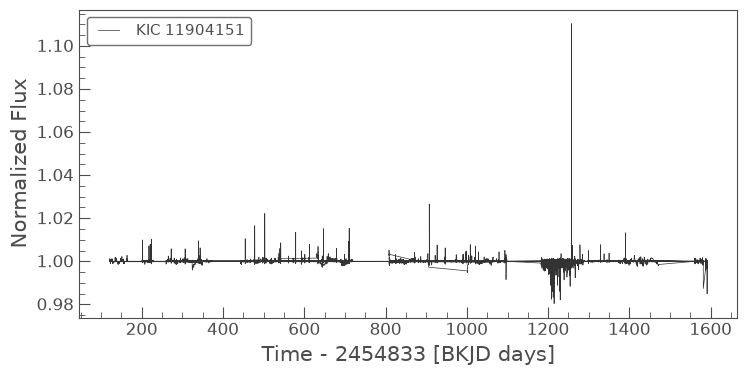

In [5]:
processed_lc.plot()
plt.show()

In [6]:
features = extract_transit_features(
    processed_lc.time.value,
    processed_lc.flux.value
)

print(features)

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 36 durations
Searching 75658 data points, 31261 periods from 1.0 to 10.0 days
Using all 14 CPU threads


100%|██████████| 31261/31261 periods | 03:55<00:00


Searching for best T0 for period 1.67496 days
{'period': 1.6749569222005023, 'duration': 0.04795851289581217, 'depth': 0.9999194937679383}


In [7]:
phase, folded_flux = fold_curve(
    processed_lc.time.value,
    processed_lc.flux.value,
    features["period"]
)

In [8]:
print(
    phase.shape,
    folded_flux.shape
)

(1513160,) (1513160,)


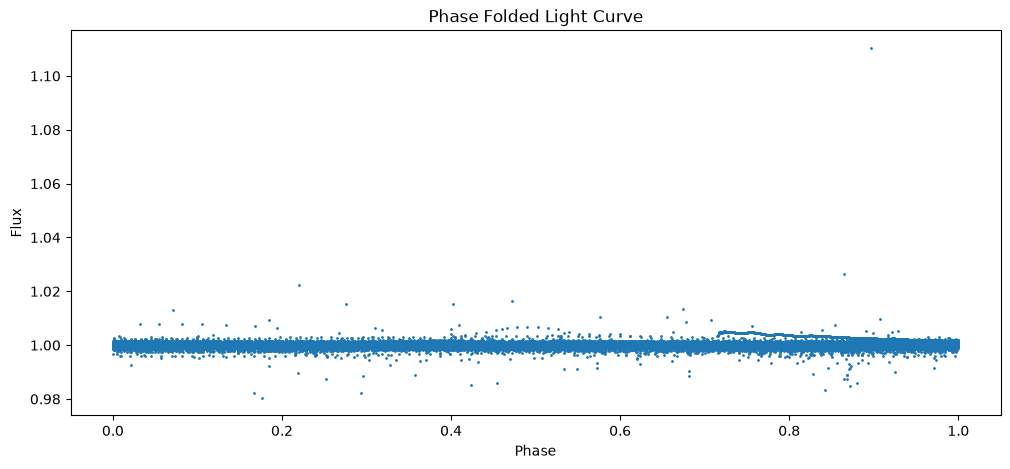

In [9]:
plt.figure(figsize=(12,5))

plt.scatter(
    phase,
    folded_flux,
    s=1
)

plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Phase Folded Light Curve")

plt.show()

In [10]:
curve_2000 = resample_curve(
    phase,
    folded_flux,
    n_points=2000
)

In [11]:
print(
    curve_2000.shape
)

(2000,)


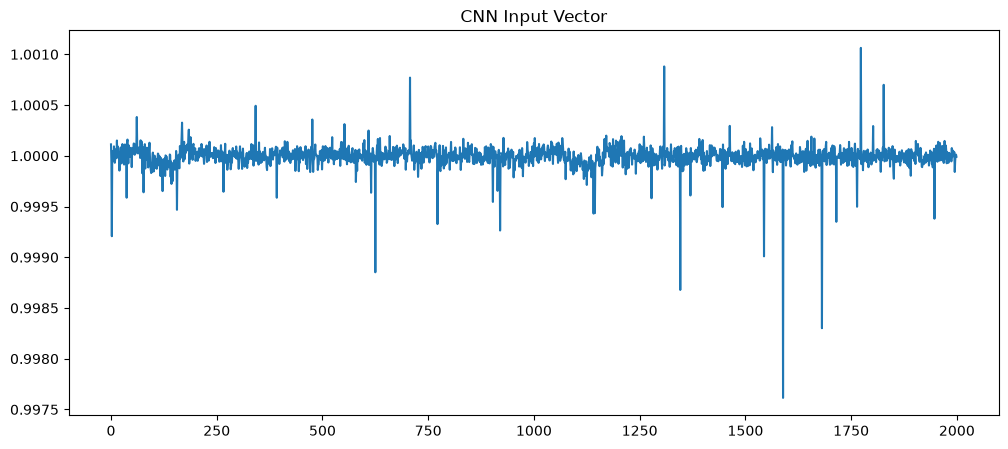

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    curve_2000
)

plt.title(
    "CNN Input Vector"
)

plt.show()

In [13]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [14]:
np.save(
    "../data/processed/sample_curve.npy",
    curve_2000
)

In [15]:
loaded = np.load(
    "../data/processed/sample_curve.npy"
)

print(
    loaded.shape
)

(2000,)
